<a href="https://colab.research.google.com/github/siddharth10-dev/machine_learning_practs/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
train=pd.read_csv('titanic_train.csv')

In [9]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Survived', ylabel='count'>

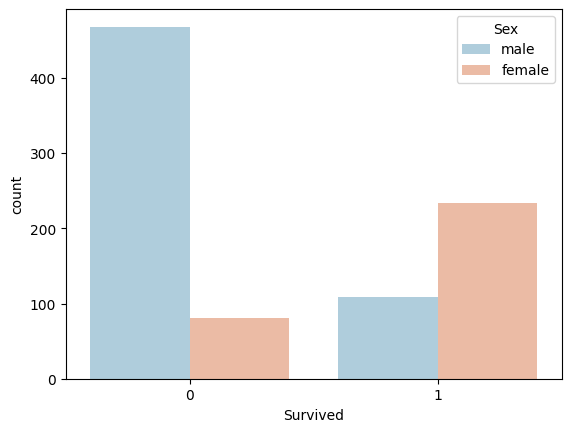

In [12]:
sns.countplot(x='Survived',hue='Sex',data=train,palette='RdBu_r')


<Axes: xlabel='Survived', ylabel='count'>

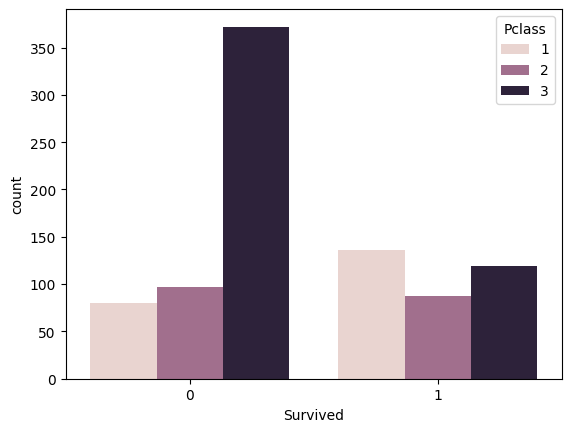

In [14]:
sns.countplot(x='Survived',hue='Pclass',data=train)

<Axes: xlabel='Survived', ylabel='count'>

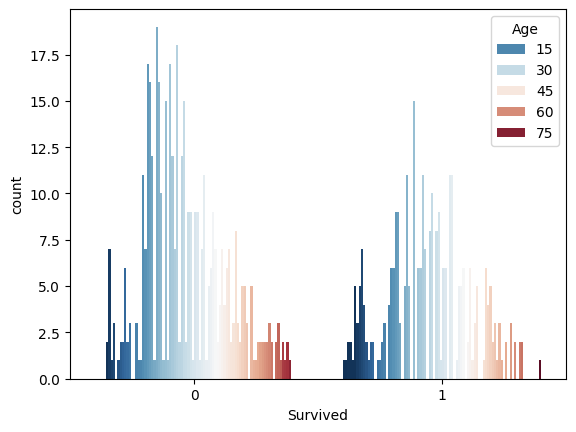

In [16]:
sns.countplot(x='Survived',hue='Age',data=train,palette='RdBu_r')

<Axes: >

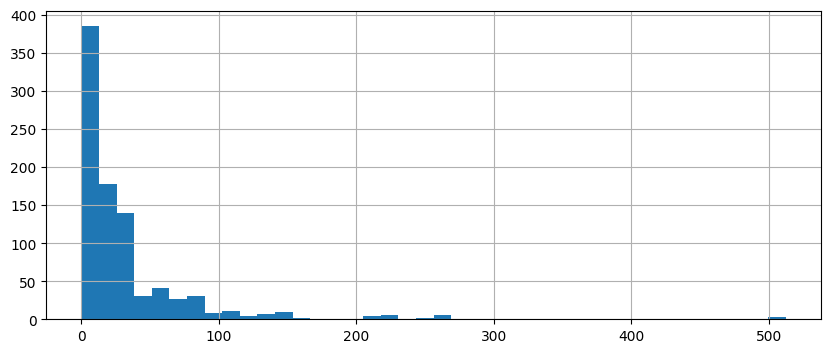

In [19]:
train['Fare'].hist(bins=40,figsize=(10,4))

In [20]:
import cufflinks as cf
cf.go_offline()

<Axes: >

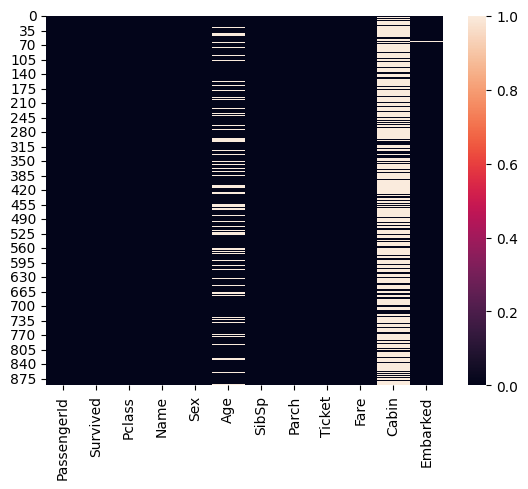

In [27]:
sns.heatmap(train.isnull())

<Axes: xlabel='Pclass', ylabel='Age'>

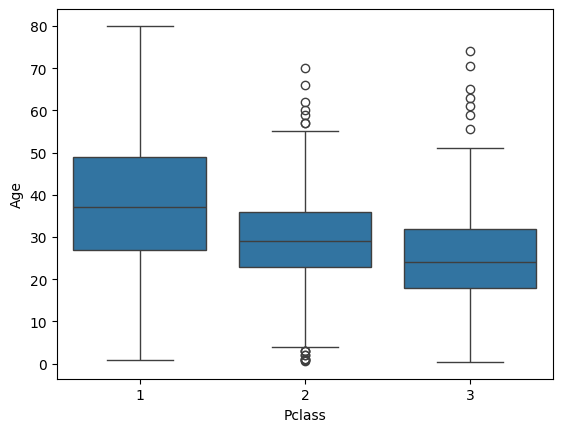

In [30]:
sns.boxplot(x='Pclass',y='Age',data=train)

In [31]:
def impute_age(cols):
    Age=cols[0]
    Pclass=cols[1]
    if pd.isnull(Age):
        if Pclass==1:
            return 37
        elif Pclass==2:
            return 29
        else:
            return 24
    else:
        return Age


In [32]:
train['Age']=train[['Age','Pclass']].apply(impute_age,axis=1)

/tmp/ipykernel_24207/1717976871.py:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_24207/1717976871.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



<Axes: >

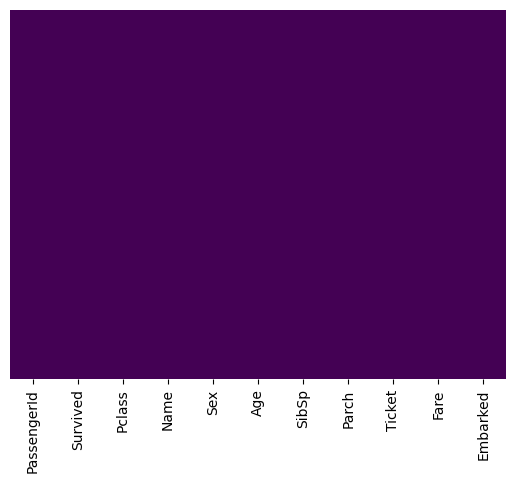

In [41]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [37]:
train.drop('Cabin', axis=1, inplace=True)

In [58]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True,False,True,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,False,False,False,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False,False,True,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,False,False,True,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True,False,True,1,0,1


In [40]:
train.dropna(inplace=True)

In [55]:
sex = pd.get_dummies(train['Sex'], drop_first=True, dtype=int)
embark = pd.get_dummies(train['Embarked'], drop_first=True, dtype=int)

In [56]:
sex.head()

,male
0,1
1,0
2,0
3,0
4,1


In [57]:
train=pd.concat([train,sex,embark],axis=1)

In [62]:
train.drop(['Sex', 'Embarked', 'Name', 'Ticket'], axis=1, inplace=True)
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True,1,0,1
1,2,1,1,38.0,1,0,71.2833,False,False,False,0,0,0
2,3,1,3,26.0,0,0,7.9250,False,False,True,0,0,1
3,4,1,1,35.0,1,0,53.1000,False,False,True,0,0,1
4,5,0,3,35.0,0,0,8.0500,True,False,True,1,0,1


In [73]:
train.drop(['Pclass'],axis=1,inplace=True)

In [74]:
train.head()

,Survived,Age,SibSp,Parch,Fare,male,Q,S,male,Q,S,2,3
0,0,22.0,1,0,7.2500,True,False,True,1,0,1,0,1
1,1,38.0,1,0,71.2833,False,False,False,0,0,0,0,0
2,1,26.0,0,0,7.9250,False,False,True,0,0,1,0,1
3,1,35.0,1,0,53.1000,False,False,True,0,0,1,0,0
4,0,35.0,0,0,8.0500,True,False,True,1,0,1,0,1


In [65]:
Pclass=pd.get_dummies(train['Pclass'],drop_first=True,dtype=int)

In [66]:
Pclass.head()

,2,3
0,0,1
1,0,0
2,0,1
3,0,0
4,0,1


In [67]:
train=pd.concat([train,Pclass],axis=1)

In [75]:
X=train.drop('Survived',axis=1)
y=train['Survived']

In [78]:
from sklearn.model_selection import train_test_split

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33,random_state=101)

In [81]:
from sklearn.linear_model import LogisticRegression

In [82]:
logmodel=LogisticRegression()

In [85]:

X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)


logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [86]:
predictions=logmodel.predict(X_test)

In [89]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.81      0.91      0.85       174
           1       0.84      0.68      0.75       120

    accuracy                           0.82       294
   macro avg       0.82      0.80      0.80       294
weighted avg       0.82      0.82      0.81       294

